# Traffic Crashes in the City of San Francisco

## About the data

**Source:** This data contains public information about the crashes resulting in an injury in the City of San Francisco. The data was pulled from `TransBASE.sfgov.org` in July 2024. There are several types of report; this data is based on the "Traffic Crashes Resulting in Injury: Parties Involved" found in https://data.sfgov.org/d/8gtc-pjc6/). 

**Preprocessing**: Some columns from the original data were dropped. For those remaining, data were modified to group values that had very similar or the same meaning. The resulting data is available on GitHub `https://github.com/D-G-D/Python/blob/main/Data/sf_traffic.csv`.

**Data format**: Each row of the data contains the information about a party involved in an accident. The row contains also information about the accident itself, that is the same for all parties (for example: the road where the accident occurred). The following columns are available: 

- `unique_id`: a unique identifier for each record.
- `case_id_pkey`: the unique identifier of the crash case.
- `tb_latitude`: latitude of the location where the collision occurred.
- `tb_longitude`: longitude of the location where the collision occurred.
- `collision_datetime`: date and time when the collision took place.
- `officer_id`: an ID of the officer who wrote the crash report.
- `primary_rd`: the road where the collision occurred.
- `secondary_rd`: a secondary reference road that `distance` and `direction` are measured from.
- `distance`: distance in ft from a known reference point (often the nearest milepost or intersection).
- `direction`: direction of `distance`.
- `weather_1`: primary weather condition at the time of the collision.
- `weather_2`: additional weather condition at the time of the collision.
- `collision_severity`: the severity level of the crash (i.e., the highest level of injury sustained in the crash).
- `type_of_collision`: the general type of crash as determined by the first injury or damage-causing event.
- `mviw`: motor vehicle involved with; describes what, in conjunction with a motor vehicle in-transport, caused the first injury or damage, whether on or off the road.
- `ped_action`: the action just prior to the crash of the first pedestrian injured or otherwise involved.    
- `road_surface`: roadway surface condition at the time of the crash in the traffic lane(s) involved.    
- `road_cond_1`: roadway condition at the time of the crash in the traffic lane(s) involved..
- `road_cond_2`: road condition, if a second description is necessary.
- `lighting`: lighting conditions at the crash location and the time of the crash.
- `control_device`: presence and condition of crash related traffic control devices at the time of the crash. Control devices include regulatory, warning, and construction signs. This excludes striping and officers or other persons directing traffic.
- `vz_pcf_description`: description of the California vehicle code primary collision factor violated.
- `dph_col_grp_description`: description of crash groupings.
- `party_number_ckey`: a unique identifier for each party involved in the crash. Used in combination with `case_id_pkey` to identify unique party.    
- `party_type`: type of party involved.
- `at_fault`: indicates if the party was at fault for the crash (Yes/No).
- `party_sex`: gender of the party involved.
- `party_age`: age of the party involved.
- `race`: racial classification of the party involved.
- `party_sobriety`: the state of sobriety of the party.    
- `party_safety_equip_1`: safety equipment used by the party (e.g. seat belt).
- `party_safety_equip_2`: additional safety equipment used by the party, if any.
- `finan_respons`: financial responsibility of the party.
- `party_number_killed`: number of fatalities for the party involved.
- `party_number_injured`: number of injuries for the party involved.    
- `move_pre_acc`: movement of the party before the collision.
- `vehicle_year`: year of the vehicle involved.
- `vehicle_make`: make/brand of the vehicle involved.
- `vehicle_age`: age of the vehicle involved in the crash, in years.
- `stwd_vehicle_type`: .
- `dir_of_travel`: .
- `street_of_travel`: .
- `Current Police Districts`: police district in which the collision occurred.
- `Current Supervisor Districts`: supervisory district where the incident occurred.
    
Note: column descriptions from https://data.sfgov.org/Public-Safety/Traffic-Crashes-Resulting-in-Injury-Parties-Involv/8gtc-pjc6/about_data and https://tims.berkeley.edu/help/SWITRS.php.

> **Analysis/Report common errors:**
>
> 1. Providing the code without the output.
> 2. The output does not match the code. This happens when you change code in a cell you previously executed.
> 3. Not using markdown text for the written answers, instead adding all the text as code comments.
> 4. Including code without referencing which question it is for.
> Re-running the notebook before submitting by going to "Kernel->Restart & Run All" makes it easy to solve first and second errors.

## Python Initialization

First, we import pandas. Then, we read the data file (a csv) as a DataFrame, and store it in the variable `df`. The column `case_id_pkey` contains mixed data types (strings mixed with numbers). Using `dtype={'case_id_pkey': str}`, we specify we want to read it as a string.

In [1]:
import pandas as pd

In [2]:
# df = pd.read_csv('https://raw.githubusercontent.com/D-G-D/Python/main/Data/sf_traffic.csv', dtype={'case_id_pkey': str})

In [3]:
df = pd.read_csv('sf_traffic.csv')

## Exploration
Add here all the code you run before answering the questions, in one or multiple code cells, and explain what you are doing.

The following is optional; I just do it to get acquainted with the data. First, I like to see the size of my DataFrame:

In [4]:
df.shape

(51531, 44)

That is 51531 rows and 44 columns. Next, I like to view a sample row to understand how the dataset looks like:

In [5]:
df.head(1)

,unique_id,case_id_pkey,tb_latitude,tb_longitude,collision_datetime,officer_id,primary_rd,secondary_rd,distance,direction,...,party_number_injured,move_pre_acc,vehicle_year,vehicle_make,vehicle_age,stwd_vehicle_type,dir_of_travel,street_of_travel,Current Police Districts,Current Supervisor Districts
0,627682,210012766,37.793229,-122.4364,2021-01-06 17:45:00,2490,STEINER ST,PACIFIC AVE,34.0,North,...,1,Slowing/Stopping,NaN,GENZE,NaN,Bicycle,North,STEINER ST.,4.0,6.0


When the DataFrame has too many columns, not all are displayed. An easy way to view all columns for a single row is to select the row using `iloc[0]`, then transform it into a dictionary:

In [6]:
df.iloc[0].to_dict()

{'unique_id': 627682,
 'case_id_pkey': 210012766,
 'tb_latitude': 37.793229,
 'tb_longitude': -122.4364,
 'collision_datetime': '2021-01-06 17:45:00',
 'officer_id': '2490',
 'primary_rd': 'STEINER ST',
 'secondary_rd': 'PACIFIC AVE',
 'distance': 34.0,
 'direction': 'North',
 'weather_1': 'Clear',
 'weather_2': 'Not Stated',
 'collision_severity': 'Injury (Complaint of Pain)',
 'type_of_collision': 'Other',
 'mviw': 'Non-Collision',
 'ped_action': 'No Pedestrian Involved',
 'road_surface': 'Dry',
 'road_cond_1': 'No Unusual Condition',
 'road_cond_2': 'Not Stated',
 'lighting': 'Dark - Street Lights',
 'control_device': 'Functioning',
 'vz_pcf_description': 'Unsafe speed for prevailing conditions',
 'dph_col_grp_description': 'Bicycle Only',
 'party_number_ckey': 1,
 'party_type': 'Bicyclist',
 'at_fault': 'Yes',
 'party_sex': 'Male',
 'party_age': 37.0,
 'race': 'Hispanic',
 'party_sobriety': 'Had Not Been Drinking',
 'party_safety_equip_1': 'Not Required',
 'party_safety_equip_2': '

Next, I want to see how the data is stored (the `Dtype`). While I could use `df.dtypes`, the `df.info()` method provides additional useful information.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51531 entries, 0 to 51530
Data columns (total 44 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   unique_id                     51531 non-null  int64  
 1   case_id_pkey                  51531 non-null  int64  
 2   tb_latitude                   51415 non-null  float64
 3   tb_longitude                  51415 non-null  float64
 4   collision_datetime            51531 non-null  object 
 5   officer_id                    49736 non-null  object 
 6   primary_rd                    51531 non-null  object 
 7   secondary_rd                  51531 non-null  object 
 8   distance                      51500 non-null  float64
 9   direction                     51531 non-null  object 
 10  weather_1                     51531 non-null  object 
 11  weather_2                     51531 non-null  object 
 12  collision_severity            51531 non-null  object 
 13  t

Most columns were loaded as strings (`object`) and some as numbers. Even though `collision_datetime` contains both date and time, it was loaded as a string. Although I'm not sure yet if I'll use the column, I’ve already converted it to a datetime format.

In [8]:
df['collision_datetime'] = pd.to_datetime(df['collision_datetime'])
df['collision_datetime'].head(4)

0   2021-01-06 17:45:00
1   2021-01-18 09:00:00
2   2018-02-13 13:10:00
3   2018-04-18 08:55:00
Name: collision_datetime, dtype: datetime64[ns]

It is now stored as a datetime (`dtype: datetime64[ns]`).

For now, I’m all set. I could explore and preprocess more columns if needed. The above is not an exhaustive approach.

> **Common errors:**
>
> 1. This section is meant for understanding the data you'll be working with, not for copying all the code you'll write later.
> 2. Skipping this section entirely. How deeply you explore is up to you, but you should always examine any new dataset before analysis.

# Questions

### Question 1. Are there any missing values in the data? If yes, what field is missing the most values?

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51531 entries, 0 to 51530
Data columns (total 44 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   unique_id                     51531 non-null  int64         
 1   case_id_pkey                  51531 non-null  int64         
 2   tb_latitude                   51415 non-null  float64       
 3   tb_longitude                  51415 non-null  float64       
 4   collision_datetime            51531 non-null  datetime64[ns]
 5   officer_id                    49736 non-null  object        
 6   primary_rd                    51531 non-null  object        
 7   secondary_rd                  51531 non-null  object        
 8   distance                      51500 non-null  float64       
 9   direction                     51531 non-null  object        
 10  weather_1                     51531 non-null  object        
 11  weather_2                   

In [10]:
(df.isna().mean().sort_values(ascending=False).head(3)*100).round(1)

vehicle_year    27.3
vehicle_age     27.3
party_age       15.5
dtype: float64

Answer: Yes. There are a total of 51,531 entries (rows), and some columns have fewer values. The columns with the most missing values are `vehicle_year` and `vehicle_age`, both missing in 27.3% of the rows.

Code deep dive:

1. `df.isna()`: returns a DataFrame of `True` and `False`, where `True` indicates a missing value.
2. `df.isna().mean()`: calculates the average of `True` values (which are treated as 1) for each column, giving the proportion of missing values.
3. `df.isna().mean().sort_values(ascending=False)`: sorts the columns in descending order by the proportion of missing values.
4. `df.isna().mean().sort_values(ascending=False).head(3)`: I keep the top value, knowing that is the highest. However, since there might be more than one column missing the same number, I show a few rows.
5. `df.isna().mean().sort_values(ascending=False).head(3)*100`: multiplying the value by 100, to convert from a value in the range [0,1] to a percentage.
6. `(df.isna().sort_values(ascending=False).head(3)*100).round(1)`: rounds the percentage to once decimal place. Note: parentheses are necessary, otherwise the `.round(1)` would only apply to the number 100, not the full expression.

> **Common errors:**
>
> 1. Not providing a written answer, forcing the reader to search through the output which column has the most missing values.

### Question 2. Are there any duplicate rows in the data? If yes, drop them.

In [11]:
df.duplicated().sum()

0

Answer: There are no duplicate rows. This is expected, as the column `unique_id` is unique and serves as the primary key of the table.

> No common errors here.

### Question 3. Are there any duplications of crash data?
Take the following list of columns `columns_list`. Are there any duplicated rows if we only look at those columns? Which % of the total they represent? Explain why this happens in the data.

In [12]:
columns_list = ['case_id_pkey', 'tb_latitude', 'tb_longitude', 'collision_datetime',
       'officer_id', 'primary_rd', 'secondary_rd', 'distance', 'direction',
       'weather_1', 'weather_2', 'collision_severity', 'type_of_collision',
       'mviw', 'ped_action', 'road_surface', 'road_cond_1', 'road_cond_2',
       'lighting', 'control_device', 'vz_pcf_description',
       'dph_col_grp_description']

In [13]:
(df[columns_list].duplicated().mean()*100).round(1)

52.3

Answer: The data refers to individual parties involved in a crash. Therefore, for all parties in the same crash, the crash-related columns will have the same values. Since most crashes involve two or more parties, many rows are duplicated when considering only the crash-related columns. In this case, they represent 52.3% of the total.

> **Common errors:**
>
> 1. Not properly justifying the reason why there are duplicates. The column list doesn't include `unique_id`, so duplicates are possible. These columns contain the same values for every party involved in the same crash.

### Question 4. Define a new column `intersection`.
The original data has a column `intersection` that isn't a Yes/No column as per the definition in the Statewide Integrated Traffic Records System (SWITRS, `https://tims.berkeley.edu/help/SWITRS.php`) codebook. Instead, it seems to define an intersection as any crash happening at most 20 feet from the intersection itself. However, there is one value `Intersection Rear End <= 150ft` that would contradict this definition.

To start, let's take any row with `distance` smaller or equal to 20 ft as an intersection. Create a column named `intersection` that is True/False based on this definition. How many rows meet the criteria?

In [14]:
df['intersection'] = df['distance'] <= 20

I have defined a new column `intersection` based on the `distance` column. The result will be a boolean because I am using the `<=` operator to compare each value in one column against a threshold.

In [15]:
df['intersection'].sum()

34968

Counting rows that meet the condition (`True`) is the same as summing them, since Python threats `True` values as 1.

Answer: A total of 34968 rows meet the intersection criteria.

> **Common errors:**
>
> 1. Using the wrong comparison (==, <, > or >= instead of <=).

### Question 5: Evaluate the impact of the "20 ft" choice.
Repeat question 4, but this time do it for all values of the distance threshold between 0 and 150 (20ft in Q4). Calculate the % of all rows that are interesctions. Plot the result (x-axis: distance threshold, y-axis: % of rows).

In [16]:
min_distance = 0
max_distance = 150

In [17]:
rows = []
for dist in range(max_distance + 1):
    df['intersection'] = df['distance'] <= dist
    rows = rows + [df['intersection'].mean()]

In [18]:
round(min(rows)*100,1)

60.2

In [19]:
round(max(rows)*100,1)

90.1

The list `rows` was generated, containing the average number of rows identified as an intersection. The index of `rows` corresponds to the distance threshold used to define an intersection.

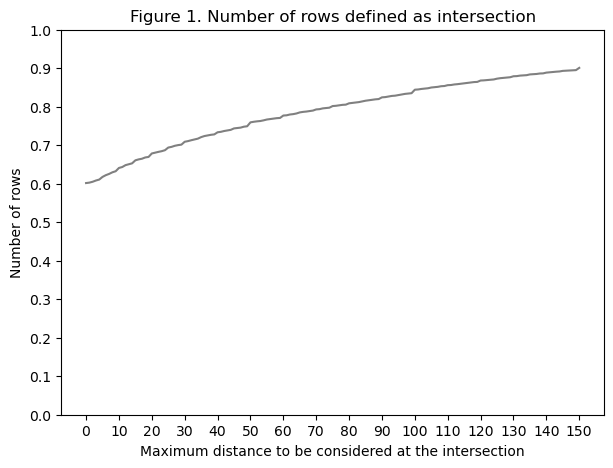

In [20]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(7,5))
plt.title('Figure 1. Number of rows defined as intersection')
plt.xlabel('Maximum distance to be considered at the intersection')
plt.ylabel('Number of rows')
plt.ylim([0, 1])
plt.plot(rows, color='gray')
plt.xticks(np.arange(min_distance, max_distance + 1, 10));
plt.yticks(np.arange(0, 1.01, 0.1));

In [21]:
df['distance'].max()

13925.0

In [22]:
round(df['distance'].max() * 0.3048 / 1000, 1) # km

4.2

Answer: The percentage of rows classified as intersections ranges from 60.2% at a threshold of 0 ft, to 90.1% at a threshold of 150 ft. As shown in the figure, the percentage increases with the threshold, converging towards the 100%. To classify 100% of the cases as an intersection, we would need to set the distance threshold at 13925ft (or ~4.2km), an unrealistic distance for defining intersections.

> **Common errors:**
>
> 1. Not calculating the percentage for each distance threshold between 0 and 150 (e.g. only using one value or calculating the frequency of the distance values).
> 2. Not formatting the plot (at a minimum, include a title and labeled axes).

### Question 6: What does the distribution of the party_number_injured column look like? When plotting it, is the default scale appropiate?

In [23]:
df['party_number_injured'].describe()

count    51531.000000
mean         0.593410
std          0.641612
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max         13.000000
Name: party_number_injured, dtype: float64

From `describe` we see that the average is ~0.6 and the distribution is highly concentrated on the values 0 and 1 (at least 25% of the values being 0, and another 25% being 1). It's better visualize the distribution with a plot.

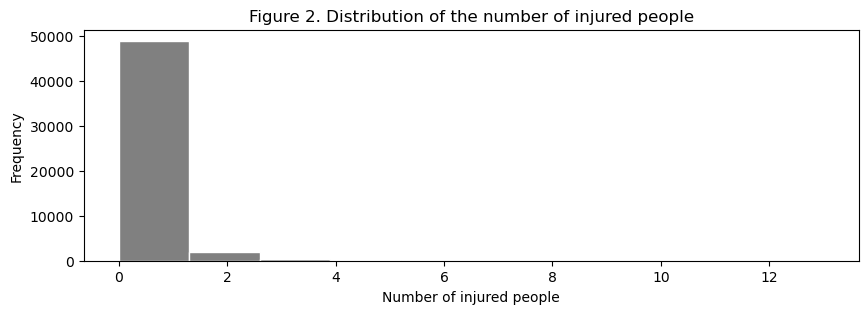

In [24]:
df['party_number_injured'].plot.hist(figsize=(10,3), 
                                     title='Figure 2. Distribution of the number of injured people', 
                                     color='gray', 
                                     edgecolor='white', 
                                     xlabel='Number of injured people');

With the default settings, we can barely see any distribution beyond the concentration at the beginning.

Choosing the number of bins is not a trivial task. Since the number of injured people goes from 0 to 13, we want a bin range that goes from 0 to 14 (or bins=15). That way, we have a bin covering \[0,1), another \[1,2), and so on until the last one \[13,14]. If we choose the bins as 0 to 13, the last bin would include both the values 12 and 13 together (see https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html).

In [25]:
df['party_number_injured'].min()

0

In [26]:
df['party_number_injured'].max()

13

In [27]:
bins = np.array(range(df['party_number_injured'].max() + 2))
bins

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14])

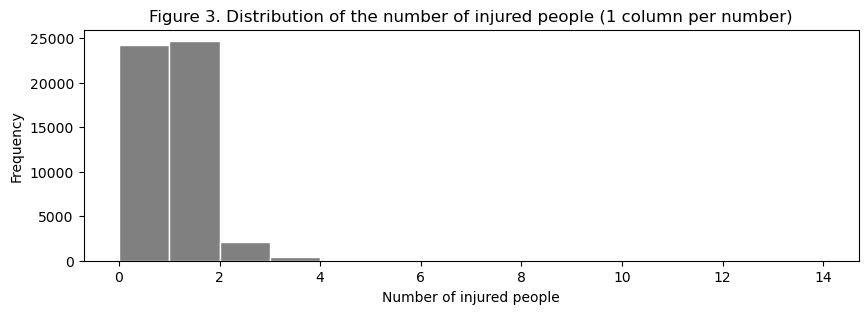

In [28]:
df['party_number_injured'].plot.hist(figsize=(10,3), 
                                     title='Figure 3. Distribution of the number of injured people (1 column per number)', 
                                     color='gray', 
                                     edgecolor='white', 
                                     xlabel='Number of injured people', 
                                     bins=bins);

I’ll improve the formatting for better readability. First, I will move the bins so that each covers ±0.5 around each integer. This will center the columns, and since the data contains no decimals (the number of injured people is an integer), the height of the bars won't change. Then, I will add more ticks on the x-axis to see all numbers.

In [29]:
bins = bins - 0.5
bins

array([-0.5,  0.5,  1.5,  2.5,  3.5,  4.5,  5.5,  6.5,  7.5,  8.5,  9.5,
       10.5, 11.5, 12.5, 13.5])

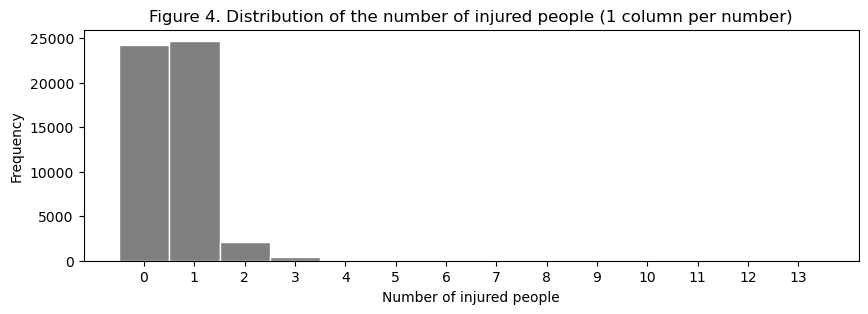

In [30]:
df['party_number_injured'].plot.hist(figsize=(10,3), 
                                     title='Figure 4. Distribution of the number of injured people (1 column per number)', 
                                     color='gray', 
                                     edgecolor='white', 
                                     xlabel='Number of injured people', 
                                     bins=bins)
import matplotlib.pyplot as plt
xticks = range(df['party_number_injured'].max() + 1)
plt.xticks(xticks);

This is better. This is better. We can see that the counts for 0 and 1 are in the same order of magnitude, but values greater than 1 are barely visible. It looks like the distribution isn't decreasing linearly, so we can try using a logarithmic scale, easily enabled with `log=True`.

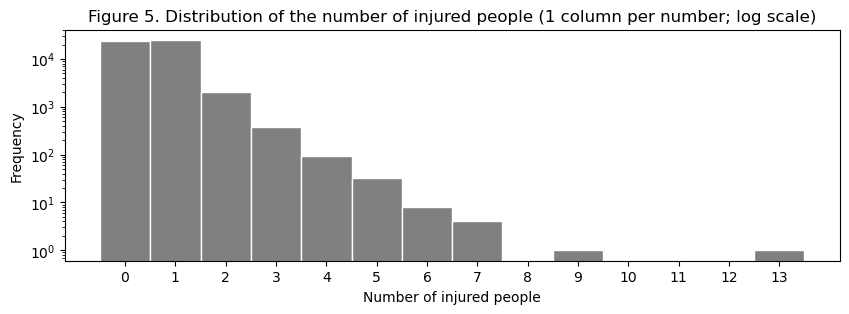

In [31]:
df['party_number_injured'].plot.hist(figsize=(10,3), 
                                     title='Figure 5. Distribution of the number of injured people (1 column per number; log scale)', 
                                     color='gray', 
                                     edgecolor='white', 
                                     xlabel='Number of injured people', 
                                     bins=bins, 
                                     log=True)
plt.xticks(xticks);

Answer: The number of people injured is concentrated at 0 and 1, both occurring with a similar frequency. The distribution likely follows an exponential or a power law distribution. We could further test the values to determine the best fit, but that is beyond the scope of this analysis.

> **Common errors:**
>
> 1. Not plotting the distribution, using only the describe() method.
> 2. Plotting without the right format (at least title and axes titles).
> 3. Not addressing the scale issue.
> 4. Not using a logarithmic scale. Adjusting the x-axis range or changing the bins doesn't fully fix the problem. The documentation of plot provides many options to configure the visualization.
> 5. Choosing an arbitrary number of bins may cause uneven amount of values to fall into the bins. This is an issue with integer values.

### Question 7. Are the columns `vehicle_year`and `vehicle_age` associated? Justify your answer.

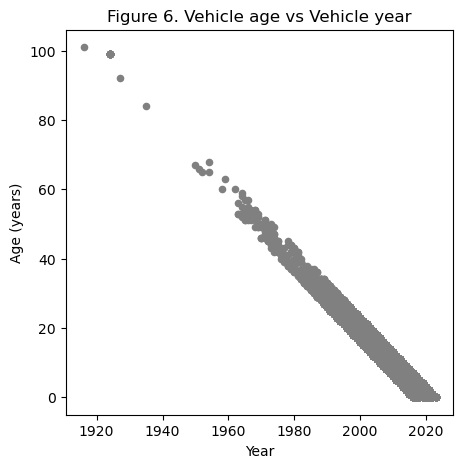

In [32]:
df.plot.scatter(x='vehicle_year', y='vehicle_age',
                title='Figure 6. Vehicle age vs Vehicle year', figsize=(5,5), color='gray',
                xlabel='Year', ylabel='Age (years)');

In [33]:
df['vehicle_year'].corr(df['vehicle_age']).round(3)

-0.954

Answer: Yes. They are highly correlated. `vehicle_age` is calculated as the year of the accident minus `vehicle_year`, so they are linearly dependent. The scatterplot does not form a single line because the data spans from 2016 to 2023. The wider the date range, the more spread out the visual pattern appears. `vehicle_age` depends on both the manufacturing year and the year of the accident, which explains why the correlation is not exactly -1.

> **Common errors:**
>
> 1. Not including an interpretation of what the correlation value or the figure means.

### Question 8. Case data for injuries and lighting.
Filter the DataFrame to keep only the columns `case_id_pkey`, `lighting` and `party_number_injured`. Then, use `.groupby()` to calculate for each combination of `case_id_pkey` and `lighting` the sum of `party_number_injured`. What is the meaning of the resulting table?

In [34]:
df[['case_id_pkey', 'lighting', 'party_number_injured']].groupby(by=['case_id_pkey', 'lighting'], as_index=False).sum()

,case_id_pkey,lighting,party_number_injured
0,16033828,Daylight,1
1,16035945,Dark - Street Lights,1
2,17008283,Dark - Street Lights,1
3,17027320,Not Stated,1
4,17045414,Dark - Street Lights,1
...,...,...,...
24561,2000096366,Dark - Street Lights,2
24562,2003336459,Daylight,1
24563,2300207389,Daylight,1
24564,9335202000557,Not Stated,0


Answer: The resulting table shows the total number of people injured in each case under specific lighting conditions, aggregated across all parties involved.

> **Common errors:**
>
> 1. Missing the meaning of the table, or partially answering (the results are per case/accident *and* lighting).

### Question 9: Investigate the impact of lighting to injuries.
First, use the code from the previous question to store the result in new variable `df_bycase`. Add `as_index=False` in the `.groupby()` to add all the values as columns instead of some as index. Then, keep the `lighting` and `party_number_injured` columns.

Use the new variable `df_bycase` to `groupby` again, this time calculating the average value of `party_number_injured` for each possible value of `lighting`. What is the meaning of the new table? What conclusions do you draw from the result?

In [35]:
columns = ['case_id_pkey', 'lighting', 'party_number_injured']
by_columns = ['case_id_pkey', 'lighting']
df_bycase = df[columns].groupby(by=by_columns, as_index=False).sum()
df_bycase = df_bycase[['lighting', 'party_number_injured']]

In [36]:
df_bycase[['lighting', 'party_number_injured']] \
    .groupby(by=['lighting']).mean() \
    .sort_values(by='party_number_injured', ascending=False)

,party_number_injured
lighting,
Dark - No Street Lights,1.268817
Dark - Street Lights,1.265881
Dark - Street Lights Not Functioning,1.239130
Daylight,1.237740
Dusk - Dawn,1.229490
Not Stated,1.116719


Answer: with the above aggregation, we calculated the average number of people injured per accident, based on the lighting conditions. We see that when it's dark and there are no street lights, the average number of people injured increases.

In [37]:
df_bycase[['lighting', 'party_number_injured']] \
    .groupby(by=['lighting']).count() \
    .sort_values(by='party_number_injured', ascending=False)

,party_number_injured
lighting,
Daylight,15559
Dark - Street Lights,7556
Dusk - Dawn,902
Not Stated,317
Dark - No Street Lights,186
Dark - Street Lights Not Functioning,46


The difference in the average number of people injured per case across categories is small. Due to the limited number of cases in some categories (see above), the precision for those estimates is low. Reporting more than two decimal places for the `Dark - No Street Lights` category may be overreaching. Additionally, the `Not Stated` cases could skew the results if their distribution differs from that of the reported values. Nonetheless, we can reasonably conclude that `Dark - No Street Lights` is likely to rank among the highest, though not necessarily at the very top.

> **Common errors:**
>
> 1. Failing to recognize that this is an aggregation of an aggregation. Often mistakenly done by applying .mean() directly on a grouped DataFrame.
> 2. Misunderstanding that the calculated average is per case (or accident), not per party (that would be if we don't do an initial aggregation per case, based on Q9).
> 3. Overlooking the importance of evaluating the relevance of the data, especially since the average values are very close. It is a minor issue.

### Question 10. Extend your analysis to other parameters.
Leveraging the code from the previous question, repeat the analysis for 2 more columns other than `lighting`. If you can, re-define the code as a function that takes the column name as a parameter.

In [38]:
def analysis(col):
    columns = ['case_id_pkey', col, 'party_number_injured']
    by_columns = ['case_id_pkey', col]
    df_bycase = df[columns].groupby(by=by_columns, as_index=False).sum()
    df_bycase = df_bycase[[col, 'party_number_injured']]
    df_results = df_bycase[[col, 'party_number_injured']].groupby(by=[col]).mean()
    return df_bycase.groupby(by=col).mean().sort_values(by='party_number_injured', ascending=False)

In [39]:
analysis('weather_1')

,party_number_injured
weather_1,
Fog,1.264368
Clear,1.251019
Cloudy,1.238542
Raining,1.208333
Wind,1.208333
Not Stated,1.143223
Other,1.039062


In [40]:
analysis('type_of_collision')

,party_number_injured
type_of_collision,
Broadside,1.378891
Head-On,1.358218
Rear End,1.356267
Overturned,1.188940
Sideswipe,1.183286
Not Stated,1.166262
Hit Object,1.147027
Other,1.065315
Vehicle/Pedestrian,1.038576


Answer: Similar to the previous analysis, we observe that foggy conditions are associated with a higher number of injuries. "Broadside" and "Head-On" crashes esult in the highest number of injuries. We could reuse the function `analysis` to examine the impact of other columns.

> **Common errors:**
>
> 1. Not defining a function. Just copying Q9 code and changing the name of the column (note: as suggested in the question, this is better than providing no answer at all).
> 2. Not commenting the results from the two new analyses. Simply identifying the worst conditions, or noting if none are relevant, is sufficient.
> 3. Not sorting the values. While it's not required by the question, it helps make the data easier to analyze.